In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
from functools import partial
import time
import glob
import pathlib
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd

import jax
import jax.numpy as jnp
import equinox as eqx


import matplotlib as mpl
from matplotlib import rc
mpl.rcParams['text.usetex'] = True
mpl.rcParams.update({'font.size': 10 * 2.54})
mpl.rcParams['text.latex.preamble']=r"\usepackage{bm}\usepackage{amsmath}"

In [ ]:
from dmpe.data_management import ClassicalSystems, DataPaths

In [ ]:
full_column_width = 18.2
half_column_width = 8.89

- all in one plot:

losses over $h$:

In [ ]:
algo_name = "dmpe"

fig, axes = plt.subplots(5,3, figsize=(half_column_width, 10), sharex="col", constrained_layout=True)

for system_idx, system_name in enumerate(ClassicalSystems):

    axs = axes[:, system_idx]
    result_path = DataPaths().sensitivity_analysis_experiments / pathlib.Path(
        f"sensitivity_analysis_data_{system_name.name.lower()}_{algo_name}.pkl"
    )
    results_df = pd.read_pickle(result_path)
    
    for idx, metric_key in enumerate(["jsd", "ae", "mcudsa", "ksfc", "df"]):
        grouped = results_df.groupby("bandwidth")[metric_key].agg(["mean", "std"]).reset_index()
    
        #print(jnp.array(grouped["bandwidth"])[jnp.argmin(jnp.array(grouped["mean"]))])
        
        axs[idx].plot(grouped["bandwidth"], grouped["mean"], linewidth=2.5, marker="x")
        axs[idx].fill_between(
            grouped["bandwidth"],
            grouped["mean"] - grouped["std"],
            grouped["mean"] + grouped["std"],
            alpha=0.3,
        )
    
        # axs[idx].axvline(
        #     x=jnp.array(grouped["bandwidth"])[jnp.nanargmin(jnp.array(grouped["mean"]))],
        #     color='red',
        #     linestyle='--',
        #     linewidth=1.5
        # )

        axes[idx, 0].set_ylabel(f"$\mathcal{{L}}_\mathrm{{{metric_key.upper()}}}$")
    
    
    for ax in axs:
        ax.grid(alpha=0.5)
        ax.tick_params(which="both", axis="y", direction="in")
        ax.tick_params(which="both", axis="x", direction="in")
        #ax.set_xscale("log")
        #ax.set_yscale("log")

    axs[-1].set_xlim(results_df["bandwidth"].min(), results_df["bandwidth"].max())
    axs[-1].set_xlabel("$h$")

axes[3, -1].set_yscale("log")

fig.align_ylabels(axes)
for ax, col in zip(axes[0], ["$\mathrm{fluid}$ $\mathrm{tank}$", "$\mathrm{pendulum}$", "$\mathrm{cart}$ $\mathrm{pole}$"]):
    ax.set_title(col)

plt.savefig(f"sensitivity_analysis_plot_all_systems_{algo_name}.pdf")
# plt.savefig(f"sensitivity_analysis_plot_all_systems_{algo_name}.png", dpi=300)

losses over $a$:

In [ ]:
def inverse_select_bandwidth(delta_z, dim, n_g, h):
    return jnp.exp(-1/2 * (delta_z / (h * n_g))**2)

# def inverse_select_bandwidth(delta_z, dim, n_g, h):
#     return jnp.exp(-dim/2 * (delta_z / (h * n_g))**2)

In [ ]:
algo_name = "dmpe"


fig, axes = plt.subplots(5,3, figsize=(half_column_width, 10), sharex="col", constrained_layout=True)

for system_idx, system_name in enumerate(ClassicalSystems):

    delta_z = 2.0
    if system_name == ClassicalSystems.FLUID_TANK:
        dim = 2
        n_g = 50
    elif system_name == ClassicalSystems.PENDULUM:
        dim = 3
        n_g = 21
    elif system_name == ClassicalSystems.CART_POLE:
        dim = 5
        n_g = 10   


    print(delta_z, dim, n_g)
    
    #####
    
    axs = axes[:, system_idx]
    result_path = DataPaths().sensitivity_analysis_experiments / pathlib.Path(
        f"sensitivity_analysis_data_{system_name.name.lower()}_{algo_name}.pkl"
    )
    results_df = pd.read_pickle(result_path)
    
    for idx, metric_key in enumerate(["jsd", "ae", "mcudsa", "ksfc", "df"]):
        grouped = results_df.groupby("bandwidth")[metric_key].agg(["mean", "std"]).reset_index()

        a = inverse_select_bandwidth(delta_z, dim, n_g, jnp.array(grouped["bandwidth"]))
        
        #print(jnp.array(grouped["bandwidth"])[jnp.argmin(jnp.array(grouped["mean"]))])
        
        axs[idx].plot(a, grouped["mean"], linewidth=2.5)#, marker="x")
        # axs[idx].fill_between(
        #     a,
        #     grouped["mean"] - grouped["std"],
        #     grouped["mean"] + grouped["std"],
        #     alpha=0.3,
        # )
    
        # axs[idx].axvline(
        #     x=a[jnp.nanargmin(jnp.array(grouped["mean"]))],
        #     color='red',
        #     linestyle='--',
        #     linewidth=1.5
        # )

        axes[idx, 0].set_ylabel(f"$\mathcal{{L}}_\mathrm{{{metric_key.upper()}}}$")
    
    
    for ax in axs:
        ax.grid(alpha=0.5)
        ax.tick_params(which="both", axis="y", direction="in")
        ax.tick_params(which="both", axis="x", direction="in")
        #ax.set_xscale("log")
        #ax.set_yscale("log")

    #axs[-1].set_xlim(0.1, 0.3)
    axs[-1].set_xlabel("$a$")

axes[3, -1].set_yscale("log")

fig.align_ylabels(axes)
for ax, col in zip(axes[0], ["$\mathrm{fluid}$ $\mathrm{tank}$", "$\mathrm{pendulum}$", "$\mathrm{cart}$ $\mathrm{pole}$"]):
    ax.set_title(col)

# axes[0, 0].set_ylim(0.045, 0.06)
# axes[0, 1].set_ylim(0.02, 0.06)
# axes[0, 2].set_ylim(0.325, 0.38)

plt.savefig(f"a_based_sensitivity_analysis_plot_all_systems_{algo_name}.pdf")
# plt.savefig(f"sensitivity_analysis_plot_all_systems_{algo_name}.png", dpi=300)

In [ ]:
raise

In [ ]:
algo_name = "dmpe"

fig, axes = plt.subplots(5,3, figsize=(half_column_width, 10), sharex="col", constrained_layout=True)

for system_idx, system_name in enumerate(ClassicalSystems):

    delta_z = 2.0
    if system_name == ClassicalSystems.FLUID_TANK:
        dim = 2
        n_g = 50
    elif system_name == ClassicalSystems.PENDULUM:
        dim = 3
        n_g = 21
    elif system_name == ClassicalSystems.CART_POLE:
        dim = 5
        n_g = 10 

    #####
    
    axs = axes[:, system_idx]
    result_path = DataPaths().sensitivity_analysis_experiments / pathlib.Path(
        f"sensitivity_analysis_data_{system_name.name.lower()}_{algo_name}.pkl"
    )
    results_df = pd.read_pickle(result_path)
    
    for idx, metric_key in enumerate(["jsd", "ae", "mcudsa", "ksfc", "df"]):
        grouped = results_df.groupby("bandwidth")[metric_key].agg(["mean", "std"]).reset_index()
    
        #print(jnp.array(grouped["bandwidth"])[jnp.argmin(jnp.array(grouped["mean"]))])
        
        axs[idx].plot(grouped["bandwidth"], grouped["mean"], linewidth=2.5, color="tab:blue") #, marker="x")
        axs[idx].fill_between(
            grouped["bandwidth"],
            grouped["mean"] - grouped["std"],
            grouped["mean"] + grouped["std"],
            alpha=0.3,
            color="tab:blue",
        )

        ax2 = axs[idx].twiny()

        a = inverse_select_bandwidth(delta_z, dim, n_g, jnp.array(grouped["bandwidth"]))       
        ax2.plot(a, grouped["mean"], linewidth=2.5, color="tab:orange",) #, marker="x")
        ax2.fill_between(
            a,
            grouped["mean"] - grouped["std"],
            grouped["mean"] + grouped["std"],
            alpha=0.3,
            color="tab:orange",
        )

        axes[idx, 0].set_ylabel(f"$\mathcal{{L}}_\mathrm{{{metric_key.upper()}}}$")
    
    
    for ax in axs:
        ax.grid(alpha=0.5)
        ax.tick_params(which="both", axis="y", direction="in")
        ax.tick_params(which="both", axis="x", direction="in")
        #ax.set_xscale("log")
        #ax.set_yscale("log")

    axs[-1].set_xlim(results_df["bandwidth"].min(), results_df["bandwidth"].max())
    axs[-1].set_xlabel("$h$")

axes[3, -1].set_yscale("log")

fig.align_ylabels(axes)
for ax, col in zip(axes[0], ["$\mathrm{fluid}$ $\mathrm{tank}$", "$\mathrm{pendulum}$", "$\mathrm{cart}$ $\mathrm{pole}$"]):
    ax.set_title(col)

plt.savefig(f"both_sensitivity_analysis_plot_all_systems_{algo_name}.pdf")
# plt.savefig(f"sensitivity_analysis_plot_all_systems_{algo_name}.png", dpi=300)

In [ ]:
raise

In [ ]:
algo_name = "dmpe"

h_mins = []
a_mins = []

for system_name in ClassicalSystems:

    delta_z = 2.0
    if system_name == ClassicalSystems.FLUID_TANK:
        dim = 2
        n_g = 50
    elif system_name == ClassicalSystems.PENDULUM:
        dim = 3
        n_g = 21
    elif system_name == ClassicalSystems.CART_POLE:
        dim = 5
        n_g = 10  
    
    
    result_path = DataPaths().sensitivity_analysis_experiments / pathlib.Path(
        f"sensitivity_analysis_data_{system_name.name.lower()}_{algo_name}.pkl"
    )
    
    
    results_df = pd.read_pickle(result_path)
    for idx, metric_key in enumerate(["jsd", "ae", "mcudsa", "ksfc", "df"]):
        grouped = results_df.groupby("bandwidth")[metric_key].agg(["mean", "std"]).reset_index()
        min_idx = jnp.nanargmin(jnp.array(grouped["mean"]))
        h_min = np.array(grouped["bandwidth"])[min_idx]
    
        a = inverse_select_bandwidth(delta_z, dim, n_g, jnp.array(grouped["bandwidth"]))
        a_min = a[min_idx]
    
        # print(min_idx)
        # print(h_min)
        print(a_min)

        h_mins.append(h_min)
        a_mins.append(a_min)

In [ ]:
plt.plot(h_mins)

In [ ]:
plt.plot(a_mins)

In [ ]:
system_name = ClassicalSystems.CART_POLE
algo_name = "dmpe"

In [ ]:
result_path = DataPaths().sensitivity_analysis_experiments / pathlib.Path(
    f"sensitivity_analysis_data_{system_name.name.lower()}_{algo_name}.pkl"
)
results_df = pd.read_pickle(result_path)

In [ ]:
results_df[results_df['ae']==results_df['ae'].min()]

In [ ]:
from dmpe.evaluation.experiment_utils import get_experiment_ids, load_experiment_results

In [ ]:
params, observations, actions, _ = load_experiment_results(
    exp_id="2026-05-14_03-14-59",
    results_path=(DataPaths().sensitivity_analysis_experiments
        / pathlib.Path(algo_name)
        / pathlib.Path(system_name.name.lower())
    ),
)

In [ ]:
plt.plot(observations)

In [ ]:
h_plot = jnp.linspace(0.0, 0.4, 1000)

plt.plot(h_plot, inverse_select_bandwidth(2, 3, 20, h_plot))

In [ ]:
x = jnp.linspace(0.001, 10, 1000)
y = jnp.exp(- 1 / x**2)

plt.plot(x,y)

In [ ]:
x = jnp.linspace(0.001, 0.8, 1000)
y = 1 / jnp.sqrt(-jnp.log(x))

plt.plot(x,y)

---

In [ ]:
system_name = ClassicalSystems.CART_POLE
algo_name = "dmpe"

In [ ]:
result_path = DataPaths().sensitivity_analysis_experiments / pathlib.Path(
    f"sensitivity_analysis_data_{system_name.name.lower()}_{algo_name}.pkl"
)
results_df = pd.read_pickle(result_path)

In [ ]:
fig, axs = plt.subplots(5,1, figsize=(10, 8), sharex=True, constrained_layout=True)

fig.suptitle(system_name.name.lower())

for idx, metric_key in enumerate(["jsd", "ae", "mcudsa", "ksfc", "df"]):

    grouped = results_df.groupby("bandwidth")[metric_key].agg(["mean", "std"]).reset_index()

    print(jnp.array(grouped["bandwidth"])[jnp.argmin(jnp.array(grouped["mean"]))])
    
    axs[idx].plot(grouped["bandwidth"], grouped["mean"]) #, marker="x")
    axs[idx].fill_between(
        grouped["bandwidth"],
        grouped["mean"] - grouped["std"],
        grouped["mean"] + grouped["std"],
        alpha=0.3,
    )

    axs[idx].axvline(
        x=jnp.array(grouped["bandwidth"])[jnp.argmin(jnp.array(grouped["mean"]))],
        color='red',
        linestyle='--',
        linewidth=1.5
    )
    
    axs[idx].set_ylabel(metric_key)


for ax in axs:
    ax.grid(alpha=0.5)
    ax.tick_params(which="both", axis="y", direction="in")
    ax.tick_params(which="both", axis="x", direction="in")
    #ax.set_xscale("log")
    ax.set_yscale("log")

    
axs[-1].set_xlim(results_df["bandwidth"].min(), results_df["bandwidth"].max())
axs[-1].set_xlabel("$h$")

plt.savefig(f"sensitivity_analysis_plot_{system_name.name.lower()}_{algo_name}.png", dpi=300)

#plt.show()

In [ ]:
raise

### Visualize over a (as defined in paper):

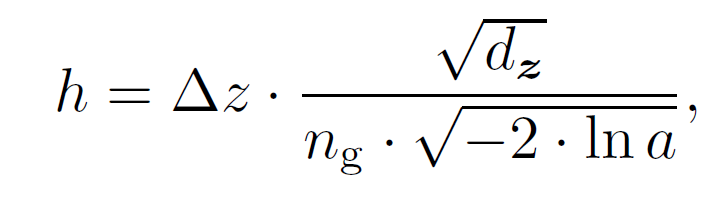

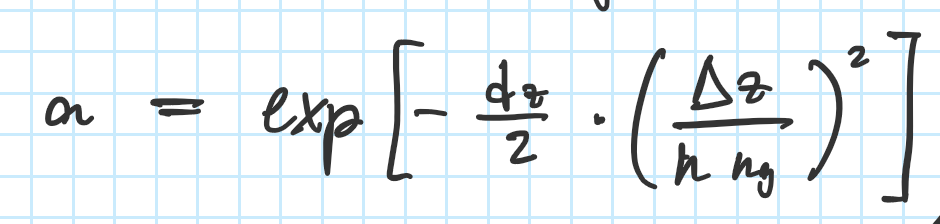

In [ ]:
def inverse_select_bandwidth(delta_z, dim, n_g, h):
    return jnp.exp(-dim/2 * (delta_z / (h * n_g))**2)

In [ ]:
system_name = ClassicalSystems.CART_POLE
algo_name = "dmpe"

####

for system_name in ClassicalSystems:

    delta_z = 2.0
    if system_name == ClassicalSystems.FLUID_TANK:
        dim = 2
        n_g = 50
    elif system_name == ClassicalSystems.PENDULUM:
        dim = 3
        n_g = 21
    elif system_name == ClassicalSystems.CART_POLE:
        dim = 5
        n_g = 10    
    
    result_path = DataPaths().sensitivity_analysis_experiments / pathlib.Path(
        f"sensitivity_analysis_data_{system_name.name.lower()}_{algo_name}.pkl"
    )
    results_df = pd.read_pickle(result_path)
    
    fig, axs = plt.subplots(5,1, figsize=(10, 8), sharex=True, constrained_layout=True)
    
    fig.suptitle(system_name.name.lower())
    
    for idx, metric_key in enumerate(["jsd", "ae", "mcudsa", "ksfc", "df"]):
    
        grouped = results_df.groupby("bandwidth")[metric_key].agg(["mean", "std"]).reset_index()
    
        a = inverse_select_bandwidth(delta_z, dim, n_g, jnp.array(grouped["bandwidth"]))
        
        axs[idx].plot(a, grouped["mean"]) #, marker="x")
        axs[idx].fill_between(
            a,
            grouped["mean"] - grouped["std"],
            grouped["mean"] + grouped["std"],
            alpha=0.3,
        )
    
        axs[idx].axvline(
            x=a[jnp.nanargmin(jnp.array(grouped["mean"]))],
            color='red',
            linestyle='--',
            linewidth=1.5
        )
        
        axs[idx].set_ylabel(metric_key)
    
    
    for ax in axs:
        ax.grid(alpha=0.5)
        ax.tick_params(which="both", axis="y", direction="in")
        ax.tick_params(which="both", axis="x", direction="in")
        #ax.set_xscale("log")
        ax.set_yscale("log")
    
        
    #axs[-1].set_xlim(0, a.max())
    axs[-1].set_xlabel("$a$")
    
    plt.savefig(f"a_based_sensitivity_analysis_plot_{system_name.name.lower()}_{algo_name}.png", dpi=300)

### With adapted $a$:
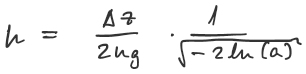

In [ ]:
def inverse_select_bandwidth(delta_z, dim, n_g, h):
    return jnp.exp(-1/2 * (delta_z / (h * n_g))**2)

In [ ]:
system_name = ClassicalSystems.CART_POLE
algo_name = "dmpe"

####

for system_name in ClassicalSystems:

    delta_z = 2.0
    if system_name == ClassicalSystems.FLUID_TANK:
        dim = 2
        n_g = 50
    elif system_name == ClassicalSystems.PENDULUM:
        dim = 3
        n_g = 21
    elif system_name == ClassicalSystems.CART_POLE:
        dim = 5
        n_g = 10    
    
    result_path = DataPaths().sensitivity_analysis_experiments / pathlib.Path(
        f"sensitivity_analysis_data_{system_name.name.lower()}_{algo_name}.pkl"
    )
    results_df = pd.read_pickle(result_path)
    
    fig, axs = plt.subplots(5,1, figsize=(10, 8), sharex=True, constrained_layout=True)
    
    fig.suptitle(system_name.name.lower())
    
    for idx, metric_key in enumerate(["jsd", "ae", "mcudsa", "ksfc", "df"]):
    
        grouped = results_df.groupby("bandwidth")[metric_key].agg(["mean", "std"]).reset_index()
    
        a = inverse_select_bandwidth(delta_z, dim, n_g, jnp.array(grouped["bandwidth"]))
        
        axs[idx].plot(a, grouped["mean"]) #, marker="x")
        axs[idx].fill_between(
            a,
            grouped["mean"] - grouped["std"],
            grouped["mean"] + grouped["std"],
            alpha=0.3,
        )
    
        axs[idx].axvline(
            x=a[jnp.argmin(jnp.array(grouped["mean"]))],
            color='red',
            linestyle='--',
            linewidth=1.5
        )
        
        axs[idx].set_ylabel(metric_key)
    
    
    for ax in axs:
        ax.grid(alpha=0.5)
        ax.tick_params(which="both", axis="y", direction="in")
        ax.tick_params(which="both", axis="x", direction="in")
        #ax.set_xscale("log")
        ax.set_yscale("log")
    
        
    axs[-1].set_xlim(a.min(), a.max())
    axs[-1].set_xlabel("$a$")
    
    plt.savefig(f"adapted_a_based_sensitivity_analysis_plot_{system_name.name.lower()}_{algo_name}.png", dpi=300)